# S05 · Five more charts worth knowing

Counting categories, comparing full distributions, drawing a trend line, and reading a matrix as colour.


**New here? Read this once.**

- Never drawn a chart in code? You can still do this whole notebook. Press
  the play button on each cell, top to bottom, and read the plain-English
  note above it.
- Every seaborn chart is the *same* call: you hand it a table, say which
  column goes across, which goes up, and it draws. That is the whole trick.
- Already know matplotlib? Look for the cells marked **Stretch (optional)**.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup
On **Google Colab**, run the next cell once. On your **own machine** you already installed everything with `uv`, so it does nothing there.

In [1]:
# seaborn ships with Colab, but we pin it up to date just in case.
import sys
if "google.colab" in sys.modules:
    !pip install -q "seaborn>=0.13"
else:
    print("Not on Colab - assuming seaborn is already installed.")

Not on Colab - assuming seaborn is already installed.


## The one line you always write first

Three imports and a theme. `pandas` holds the table, `seaborn` draws the chart, and `matplotlib` is the canvas seaborn draws on — you need it to add a title or to show the figure.

The `load` function below is a small convenience for this course. It reads the dataset from the `data/` folder when you have the course repo, and downloads it otherwise, so this notebook works even if the classroom wifi is down.

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def load(name):
    """Load a sample dataset: the copy in this repo first, else download it."""
    local = Path("../data") / f"{name}.csv"
    if local.exists():
        return pd.read_csv(local)
    return sns.load_dataset(name)


# One line, and every chart in this notebook comes out looking the same.
sns.set_theme(style="whitegrid")

print("Ready.")

Ready.


In [3]:
tips = load("tips")
flights = load("flights")

print("tips:", tips.shape, " flights:", flights.shape)

tips: (244, 7)  flights: (144, 3)


## Step 1 — `countplot`: how many rows in each category?

Sometimes you do not want to average anything, you just want to know **how many**. `countplot` counts rows per category. It is `value_counts()` drawn as bars.

Like the histogram, it takes `x` and no `y` — the height *is* the count.

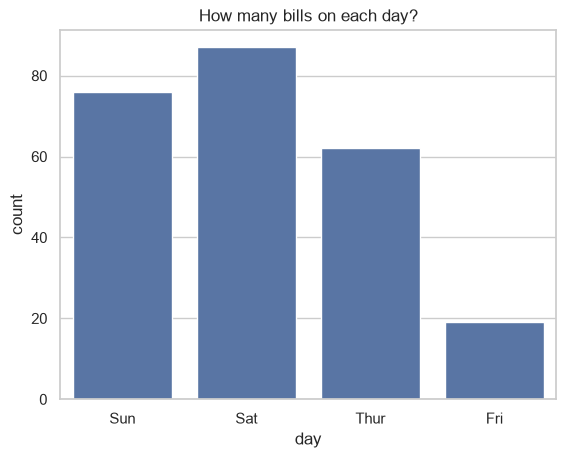

In [4]:
sns.countplot(data=tips, x="day")

plt.title("How many bills on each day?")
plt.show()

Compare it with the number pandas gives you — the same answer:

In [5]:
tips["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

This is worth pausing on. The bar plot in the last notebook showed the **average tip** per day. This one shows **how many bills** per day. Same data, same shape of chart, completely different question. Always know which one you are drawing.

## Step 2 — `violinplot`: the box plot, with the shape drawn in

A box plot tells you the median and the spread, but it hides *how* the values are distributed. A **violin plot** is the same summary with the full shape mirrored around the centre — wide where values cluster, narrow where they are sparse.

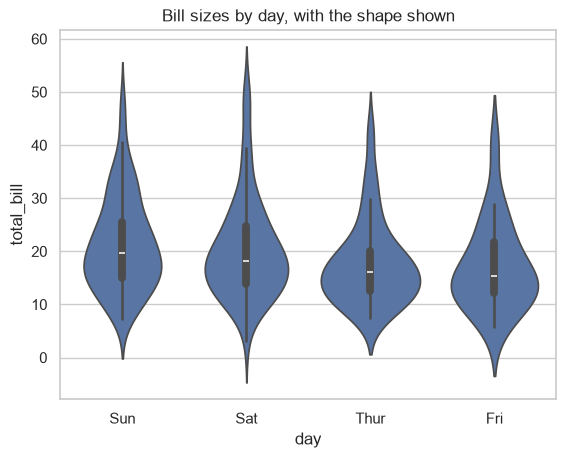

In [6]:
sns.violinplot(data=tips, x="day", y="total_bill")

plt.title("Bill sizes by day, with the shape shown")
plt.show()

Saturday's violin is fat near the bottom and tapers upward: lots of modest bills and a few big ones. A box plot would have shown you the median but not that shape.

Use a box when you have many categories and want a clean comparison. Use a violin when the shape itself is the point.

## Step 3 — `regplot`: the scatter, with a trend line

`regplot` draws a scatter and fits a straight line through it, with a shaded band showing how confident the fit is. It answers "is there a trend, and how strong?" in one picture.

This is your first sight of **regression**, which is the whole of Session 7. Today just read the line.

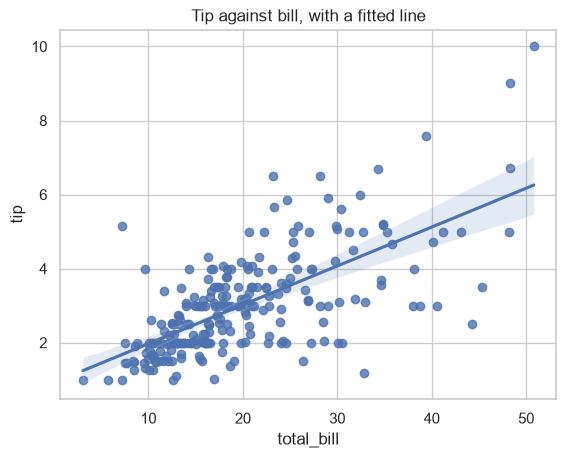

In [7]:
sns.regplot(data=tips, x="total_bill", y="tip")

plt.title("Tip against bill, with a fitted line")
plt.show()

The line slopes up, so tips do rise with the bill. The band is narrow in the middle where there is plenty of data and flares at the right where there are only a few big bills — the fit is less certain out there. Honest charts show that uncertainty rather than hiding it.

## Step 4 — `jointplot`: the relationship *and* both shapes

`jointplot` puts a scatter in the middle and a histogram along each edge, so you see the relationship and the shape of each column at once.

One catch worth knowing: `jointplot` builds its own whole figure, so you cannot place it inside a grid of subplots the way you can with the others.

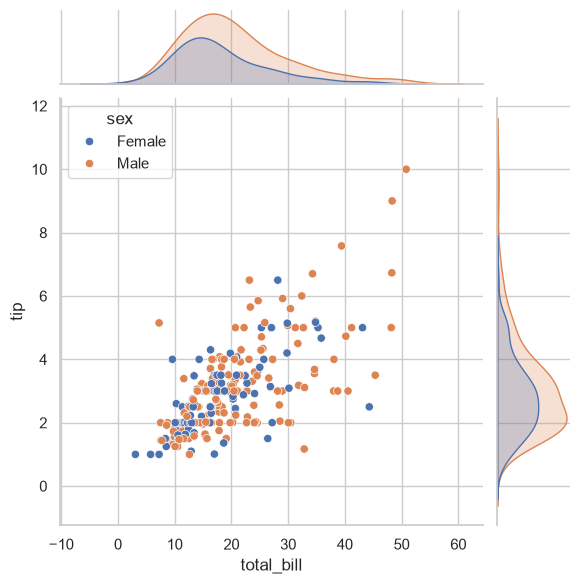

In [8]:
sns.jointplot(data=tips, x="total_bill", y="tip", hue="sex")

plt.show()

## Step 5 — `heatmap`: a table read as colour

A **heatmap** colours every cell of a rectangular table by its value. It is how you read a grid of numbers too big to scan by eye.

`heatmap` needs a table already shaped as a grid, so first we reshape `flights` with pandas `pivot`: years across, months down, passengers in the cells.

In [9]:
grid = flights.pivot(index="month", columns="year", values="passengers")

grid.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Apr,129,135,163,181,235,227,269,313,348,348,396,461
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Dec,118,140,166,194,201,229,278,306,336,337,405,432
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Jan,112,115,145,171,196,204,242,284,315,340,360,417


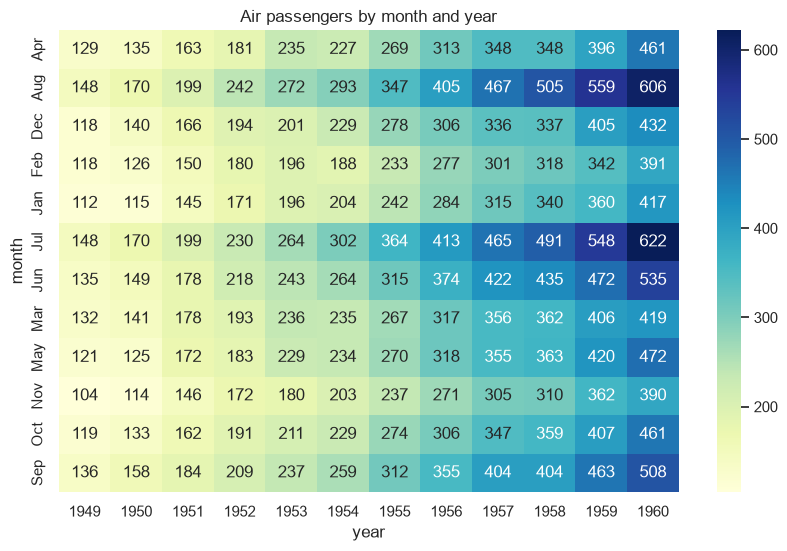

In [10]:
plt.figure(figsize=(10, 6))

sns.heatmap(grid, annot=True, fmt="d", cmap="YlGnBu")

plt.title("Air passengers by month and year")
plt.show()

Two patterns jump out that a table of numbers would have buried. Colour deepens left to right — travel grew every year. And there is a bright band across July and August every single year — the summer peak. That is the heatmap earning its place.

`annot=True` prints the number in each cell and `fmt="d"` keeps them as whole numbers. Drop `annot` when the grid is large.

### Your turn (4 min)

1. Redraw the heatmap with `cmap="coolwarm"`. Which reads better here, and why?
2. Draw a `violinplot` of `tip` by `day` and add `hue="sex"`.
3. Use `countplot` to show how many bills came at lunch vs dinner.

In [11]:
# Try all three here.

### Stretch (optional)

`FacetGrid` draws the *same* chart once per category — small multiples. When a `hue` makes a chart too crowded, split it into panels instead.

Most seaborn functions also do this directly through the `col` argument, which is usually the easier route.

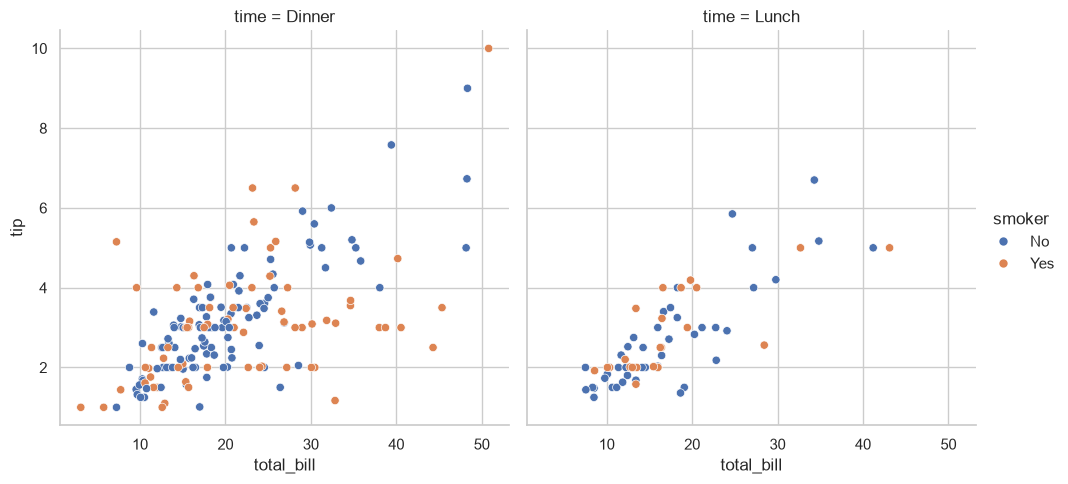

In [12]:
# The direct way: col= splits into one panel per category.
sns.relplot(data=tips, x="total_bill", y="tip",
            col="time", hue="smoker")

plt.show()

## What you can do now

| Question | Function |
|---|---|
| How many in each category? | `countplot` |
| How do full distributions compare? | `violinplot` |
| Is there a trend, and how strong? | `regplot` |
| Relationship plus both shapes? | `jointplot` |
| What does this grid of numbers say? | `heatmap` |

Next notebook: putting them together into one page you would actually show someone.